<a href="https://colab.research.google.com/github/Vittoriacrugnola/Uni/blob/main/notebooks_Notebook_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting student persistence/dropout from socio\-academic features

## Dataset overview

This project utilizes a dataset compiled from various disjoint databases of a higher education institution, focusing on students enrolled in diverse undergraduate degrees, including agronomy, design, education, nursing, journalism, management, social service, and technologies\.

The dataset contains 4424 rows and 35 columns that include information known at the time of enrollment, specifically academic path, demographics, and socio\-economic factors, and students' academic performance at the end of the first and second semesters\.

Dataset Source: https://www\.kaggle\.com/datasets/marouandaghmoumi/dropout\-and\-success\-student\-data\-analysis

Columns Include:

- Demographics & Personal Context: Marital status, Nationality, Gender, Age at enrollment, Displaced, International

- Socioeconomic Factors: Mother's qualification, Father's qualification, Mother's occupation, Father's occupation, Debtor, Tuition fees up to date, Scholarship holder

- Enrollment & Institutional Factors: Application mode, Application order, Previous qualification, Course, evening attendance, Educational special needs

- Macroeconomic Indicators: Unemployment rate, Inflation rate, GDP

- Academic Performance \(1st Semester\): Curricular units 1st sem \(credited\), Curricular units 1st sem \(enrolled\), Curricular units 1st sem \(evaluations\), Curricular units 1st sem \(approved\), Curricular units 1st sem \(grade\), Curricular units 1st sem \(without evaluations\)

- Academic Performance \(2nd Semester\): Curricular units 2nd sem \(credited\), Curricular units 2nd sem \(enrolled\), Curricular units 2nd sem \(evaluations\), Curricular units 2nd sem \(approved\), Curricular units 2nd sem \(grade\), Curricular units 2nd sem \(without evaluations\)

## Project objective

The goal of this project is to predict a student's overall academic outcome at a higher education institution \(classifying them as Graduate, Dropout, or Enrolled\)\.

This task is framed as a multi\-class classification problem but it will later be transformed into a binary classification problem, where we seek to build a model capable of categorizing students into their final academic status \(is\_dropout y/n\) based on measurable data, providing valuable insights for educators, policymakers, and researchers to enhance strategies for student retention and academic achievement\.

This has potential applications in:

- Early Intervention: Identifying students at high risk of dropping out before irreversible decisions are made\.

- Resource Allocation: Directing advising, tutoring, and financial support resources to where they can have the greatest impact\.

- Curriculum Review: Pinpointing specific academic metrics that are the strongest predictors of success or failure\.

## Installing and importing libraries

In [ ]:
import math
import itertools
import warnings
import numpy as np
import pandas as pd
from scipy.stats import uniform, randint, loguniform

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    OneHotEncoder,
    LabelEncoder,
    FunctionTransformer,
    PowerTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.pipeline import Pipeline
from sklearn import set_config
from imblearn.pipeline import Pipeline as IMBPipeline

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    KFold,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
    cross_validate,
    learning_curve,
    validation_curve
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    make_scorer,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

%matplotlib inline
warnings.filterwarnings("ignore")

## Data loading

First, let's upload the dataset \(we will call it df\)\. Then we'll take a first glance at its structure and move onto data preprocessing\.

In [ ]:
df = pd.read_csv('student_data.csv', sep=';')
df

,Marital status,Application mode,Application order,Course,evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Output
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,15,1,1,1,1,1,6,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,15,1,1,19,1,1,10,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,12,1,1,1,22,27,10,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9,1,1,1,22,27,8,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


We can see that there are 35 features in total, which are many considering there is a total of 4424 rows, so they will have to be reduced later and cleared up of any unneeded ones\.

## Data preprocessing

Now we want to check what type of data is present in the dataset\.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   evening attendance                              4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

The dataset is almost entirely composed of numerical features \(int, float\), however, one column \('Output'\) has 'object' type\.

We will deal with that by converting the initial multi\-class target variable 'Output' into a binary target variable \(y/n\) 'Is\_Dropout' suitable for binary classification\. We then drop the 'Output' column\.

In [ ]:
df['Is_Dropout'] = df['Output'].map({'Dropout': 1,
                                     'Graduate': 0,
                                     'Enrolled': 0})


df = df.drop('Output', axis=1)
y = df['Is_Dropout']

We now want to ensure consistent column naming across the entire dataset\. First, we correct any spelling mistakes in the dataset, then we will standardize names to eliminate inconsistencies arising from trailing spaces and other characters\. This cleanup is essential for improving feature tracking and facilitating the overall analysis\.

In [ ]:
# Rename 'Nacionality' to 'Nationality'
df.rename(columns={'Nacionality': 'Nationality'}, inplace=True)

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^a-z0-9_]+', '', regex=True)

### Feature engineering

Before modeling, we review all available columns and identify which ones are not useful or could potentially introduce bias or data leakage\.

We notice that 'curricular\_units\_1st\_sem\_\(enrolled\)' \(same as 2nd sem\) is by itself useless since enrollment is a prerequisite for all other columns\.

We will create new features that are less redundant and that serve as immediate, quantitative proxies for the risk of a student dropping out: 'completion\_ratio' and 'engagement\_indicator'\.

completion\_ratio: is a direct measure of academic success\. A high ratio indicates the student successfully completed most of their courses for that semester\. A low completion ratio in the first semester strongly signals a student struggling to adapt, failing courses, or having poor time management\. This student would be flagged by the model as a high dropout risk\.

engagement\_indicator: a high indicator will be a strong negative predictor for dropout and a strong positive predictor for academic persistence or success\. A low engagement indicator suggests the student may have effectively abandoned their studies early in the semester, which is a near\-certain predictor of future dropout\.

In [ ]:
approved_1 = 'curricular_units_1st_sem_approved'
enrolled_1 = 'curricular_units_1st_sem_enrolled'
without_eval_1 = 'curricular_units_1st_sem_without_evaluations'

approved_2 = 'curricular_units_2nd_sem_approved'
enrolled_2 = 'curricular_units_2nd_sem_enrolled'
without_eval_2 = 'curricular_units_2nd_sem_without_evaluations'

# Calculate Completion Ratios (handling division by zero)
df['completion_ratio_1st_sem'] = np.where(
    df[enrolled_1] > 0,
    df[approved_1] / df[enrolled_1],
    0.0
)

df['completion_ratio_2nd_sem'] = np.where(
    df[enrolled_2] > 0,
    df[approved_2] / df[enrolled_2],
    0.0
)

# Calculate Engagement Indicators
df['engagement_indicator_1st_sem'] = df[enrolled_1] - df[without_eval_1]
df['engagement_indicator_2nd_sem'] = df[enrolled_2] - df[without_eval_2]

Now we go on to drop the columns that became redundant after this step\.

In [ ]:
columns_to_drop = [
    'curricular_units_1st_sem_enrolled',
    'curricular_units_2nd_sem_enrolled',
    'curricular_units_1st_sem_evaluations',
    'curricular_units_2nd_sem_evaluations',
    'curricular_units_1st_sem_without_evaluations',
    'curricular_units_2nd_sem_without_evaluations'
    ]

# Drop the columns
df = df.drop(columns=columns_to_drop, axis=1)

We retained 'curricular\_units\_1st\_sem\_approved' and 'curricular\_units\_2nd\_sem\_approved' columns because the absolute magnitude of success  is the single strongest predictor of persistence; keeping it ensures the model distinguishes between a student who passes a heavy workload and a student who merely passes one easy course, a distinction the percentage ratio alone would miss\.

Then, we perform feature selection to remove static data that do not contribute predictive signal to the model\.

- 'application\_order' and 'application\_mode': These are pre\-enrollment administrative categories\. While they describe how a student arrived, they are static historical records that become irrelevant once actual academic performance data \(grades\) is available\.

- 'international': already included in nationality\.

In [ ]:
columns_to_drop = [
    'application_order', # not a strong indicator of future academic success or struggle
    'application_mode', # not a strong indicator of future academic success or struggle
    'international' # already included in nationality
    ]


df = df.drop(columns=columns_to_drop, axis=1)

We then visualize data distributions to check the variance of the features\.

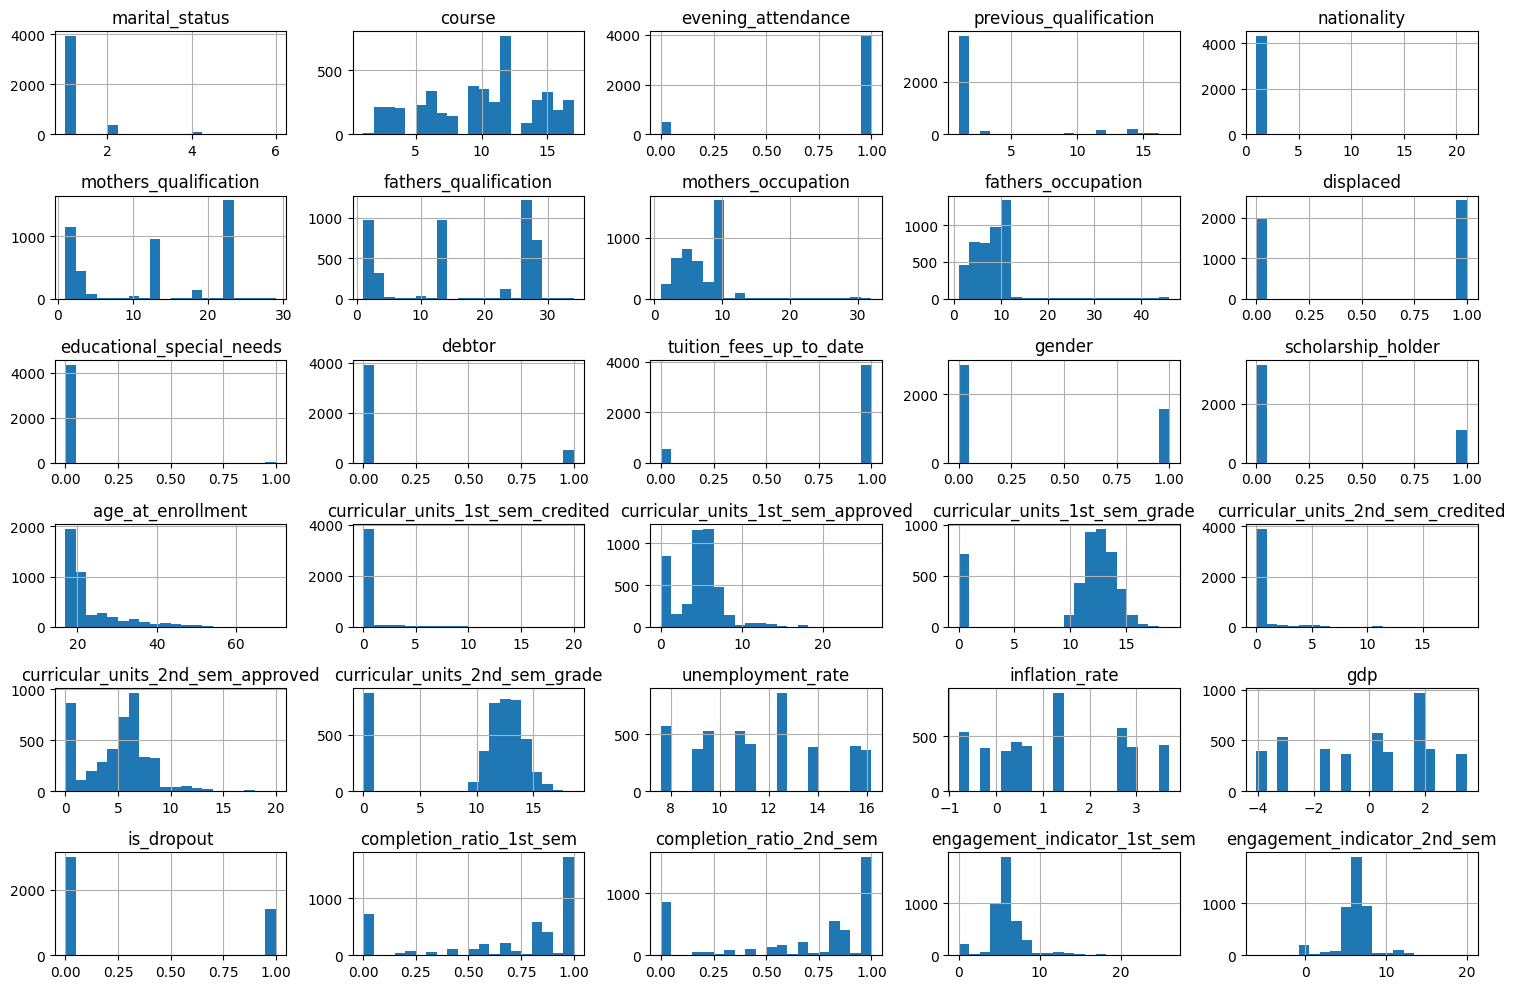

In [ ]:
df.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()


For some columns we can see that they have very low variance \(they are essentially constant\), hence they can be dropped because they have no influence on the outcome\.

In [ ]:
columns_to_drop = [
    'educational_special_needs',
    'nationality',
    'curricular_units_1st_sem_credited',
    'curricular_units_2nd_sem_credited'
]

df = df.drop(columns=columns_to_drop, axis=1)

Moreover, we detect redundant features that we could remove to avoid multicollinearity\. We know that 1st Semester performance is highly correlated with 2nd Semester performance\. The most recent data \(2nd semester\) is usually a stronger predictor of the final outcome \(Dropout vs\. Graduate\) than the older data \(1st semester\), thus we can now decide to drop the 1st semester columns\.

In [ ]:
cols_to_drop = [
    'curricular_units_1st_sem_approved',
    'curricular_units_1st_sem_grade',
    'completion_ratio_1st_sem',
    'engagement_indicator_1st_sem'
]

df = df.drop(cols_to_drop, axis=1)

### Handling missing data

Now we check the quality of our dataset by evaluating the number of missing values in each column\.

In [ ]:
df.isnull().sum(axis=0)

marital_status                       0
course                               0
evening_attendance                   0
previous_qualification               0
mothers_qualification                0
fathers_qualification                0
mothers_occupation                   0
fathers_occupation                   0
displaced                            0
debtor                               0
tuition_fees_up_to_date              0
gender                               0
scholarship_holder                   0
age_at_enrollment                    0
curricular_units_2nd_sem_approved    0
curricular_units_2nd_sem_grade       0
unemployment_rate                    0
inflation_rate                       0
gdp                                  0
is_dropout                           0
completion_ratio_2nd_sem             0
engagement_indicator_2nd_sem         0
dtype: int64

As we can see there are zero missing values in our dataset\. We can introduce missing values in both academic performance and socio\-economic variables\.

There are several reasons as to why this is a crucial step in the preparation of our dataset:

- to stress\-test the robustness of our predictive model\.

- to create a more realistic scenario that mimics what happens with real\-world data collection\.

- to avoid overfitting and poor performance when the model is deployed on real, incomplete data\. By training on data that includes known missingness, the model learns to generalize better\.

Here we choose a subset of columns onto which missing values will be added\.

In [ ]:
def add_missing(col, amount):
    X = col.copy()
    size = amount if amount >= 1 else int(len(X) * amount)
    indexes = np.random.choice(X.index, size, replace=False)
    X.loc[indexes] = np.nan
    return X

# Columns to introduce noise onto
numerical_columns_reduced = ['unemployment_rate', 'completion_ratio_2nd_sem', 'curricular_units_2nd_sem_grade']
yesno_columns_reduced = ['debtor', 'tuition_fees_up_to_date']

# 5% missing values
missing_percentage = 0.05

#apply
for column in numerical_columns_reduced + yesno_columns_reduced:
    df[column] = add_missing(df[column], missing_percentage)

print("Missing values after adding missing data:")
print(df.isnull().sum())

Missing values after adding missing data:
marital_status                         0
course                                 0
evening_attendance                     0
previous_qualification                 0
mothers_qualification                  0
fathers_qualification                  0
mothers_occupation                     0
fathers_occupation                     0
displaced                              0
debtor                               221
tuition_fees_up_to_date              221
gender                                 0
scholarship_holder                     0
age_at_enrollment                      0
curricular_units_2nd_sem_approved      0
curricular_units_2nd_sem_grade       221
unemployment_rate                    221
inflation_rate                         0
gdp                                    0
is_dropout                             0
completion_ratio_2nd_sem             221
engagement_indicator_2nd_sem           0
dtype: int64


Let's visualize our dataset to assess the presence of missing values\.

<Axes: >

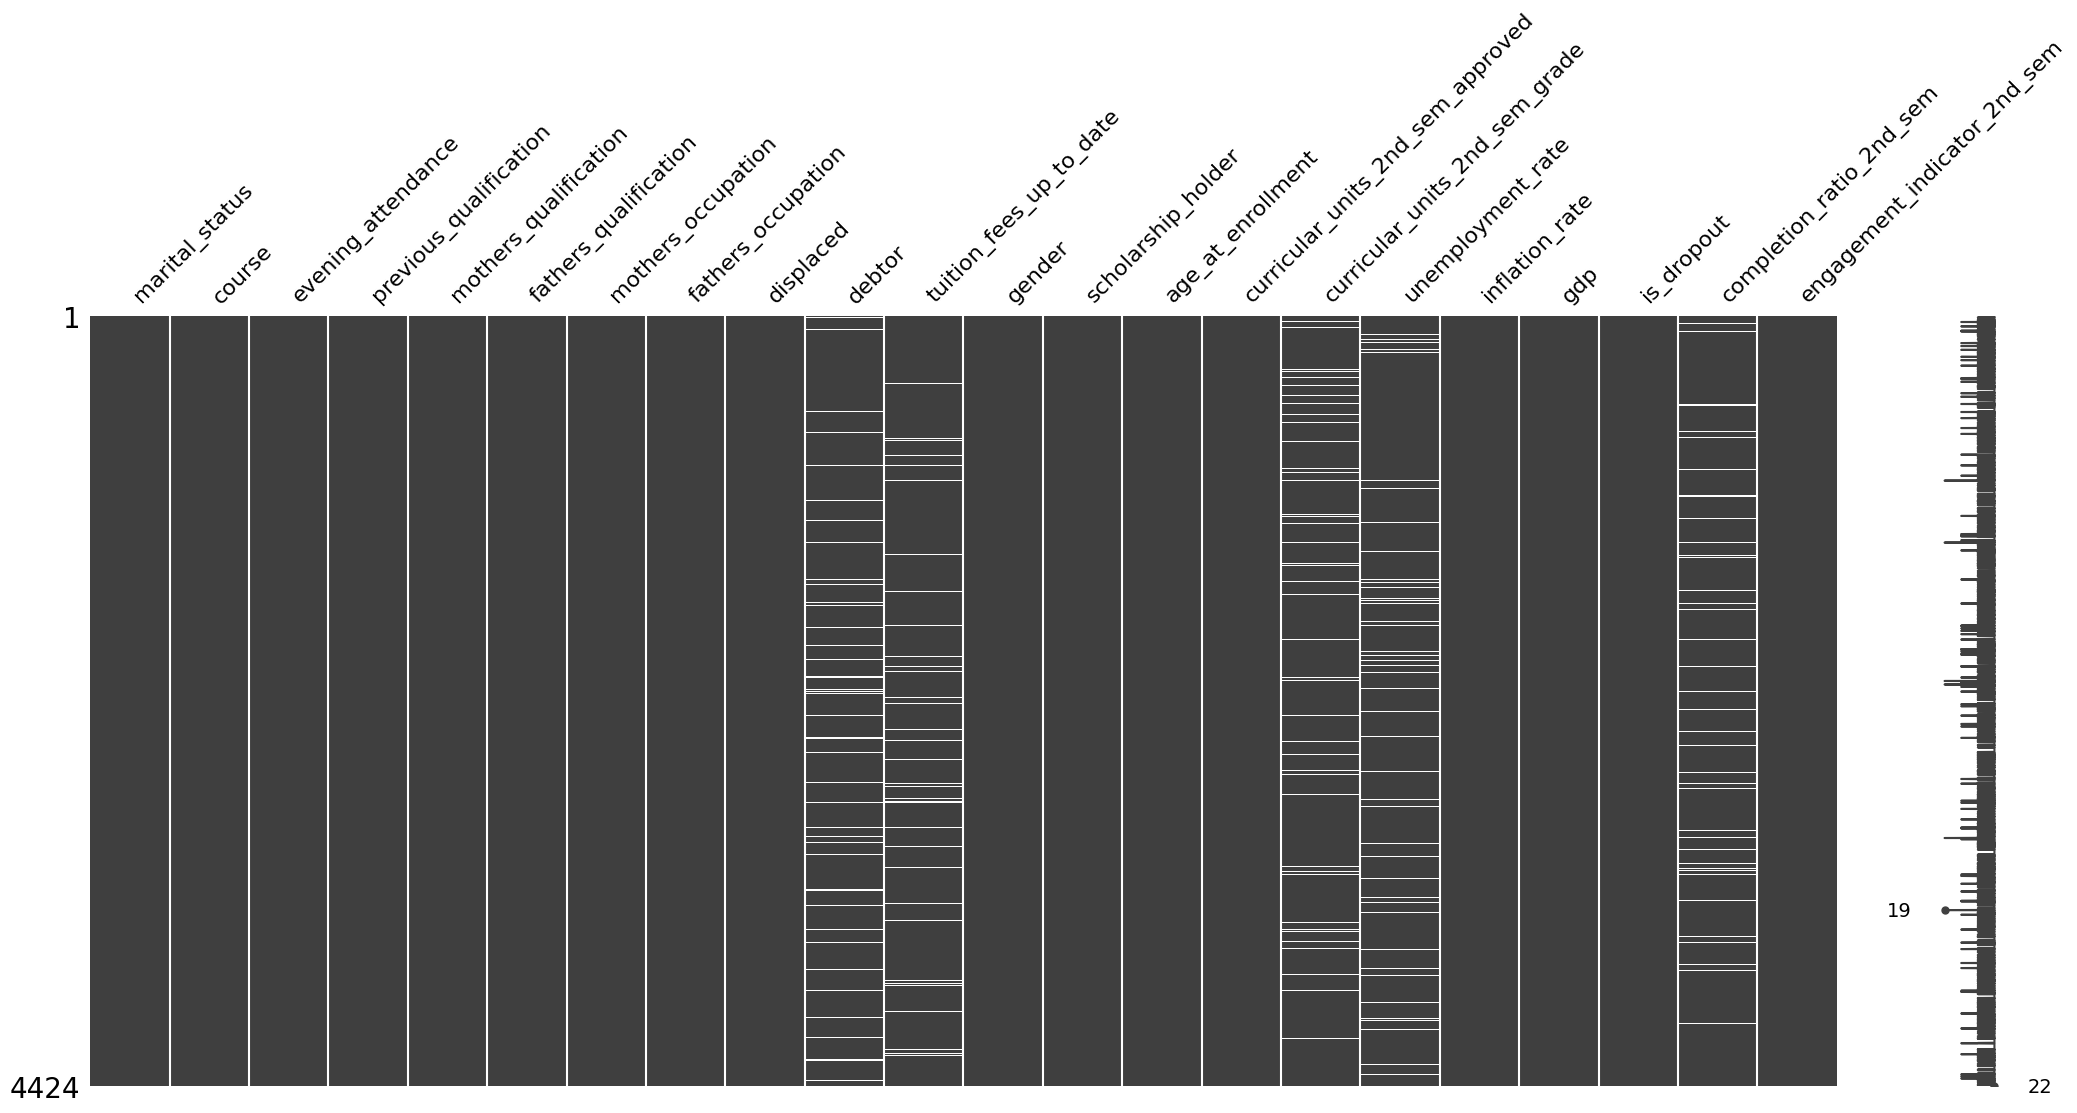

In [ ]:
msno.matrix(df)

### Preprocessing pipeline architecture

To prepare the dataset for machine learning, we design a preprocessing pipeline tailored to the nature of each column \(feature\)\.

1\. Numerical columns

In [ ]:
numerical_columns = [
    'inflation_rate',
    'gdp',
    'unemployment_rate',
    'completion_ratio_2nd_sem',
    'engagement_indicator_2nd_sem'
]

- Mean imputation \(SimpleImputer\(strategy='mean'\)\) is used to handle missing data\.

- Standard scaling \(StandardScaler\(\)\) standardizes all numerical features \(mean = 0, std = 1\), ensuring that each contributes equally during model training\.

2\. Columns that lean heavily to one side \(High Skewness\)

In [ ]:
skewed_columns = [
    'age_at_enrollment'
]

- Logarithmic transformation \(np\.log1p\) is used to fix the shape of the data\. It makes the distribution look more like a bell curve, which helps the model\. We apply log\(1\+x\) transformation because our data might contain zeros and adding 1 ensures the math always works while keeping the transformation effective\.

- Standard scaling \(StandardScaler\(\)\) standardizes all numerical features \(mean = 0, std = 1\), ensuring that each contributes equally during model training\.

In [ ]:
robust_columns = [
    'curricular_units_2nd_sem_approved',
    'curricular_units_2nd_sem_grade'
]

- Mean imputation \(SimpleImputer\(strategy='median'\)\) is used to handle missing data\.

- Robust scaling \(RobustScaler\(\)\) scales all numerical features using the median and Interquartile Range \(IQR\), reducing the influence of outliers during model training\.

3\. Binary columns

In [ ]:
yesno_columns = [
    'evening_attendance',
    'displaced',
    'gender',
    'scholarship_holder',
    'debtor',
    'tuition_fees_up_to_date'
]

- Mean imputation \(SimpleImputer\(strategy='most\_frequent'\)\) is used to handle missing data\.

4\. Nominal categorical columns

In [ ]:
# We didn't add missing values to any of these columns
nominal_categorical = [
    'marital_status',
    'course',
    'previous_qualification',
    'mothers_qualification',
    'fathers_qualification',
    'mothers_occupation',
    'fathers_occupation'
]

- Mean imputation \(SimpleImputer\(strategy='most\_frequent'\)\) is used to handle missing data\. We include an imputer \(even though we didn't add any missing values to these columns\) for clean categorical features which serves as a proactive safety mechanism to ensure the machine learning pipeline remains robust and functional if it encounters missing values in future unseen data\.

- One\-hot encoding using OneHotEncoder\(drop='first', handle\_unknown='ignore', sparse\_output=False\) to convert categories into binary columns, avoiding false ordinal relationships\.

5\. Target Variable

The column is\_dropout is the binary classification target variable \(yes/no\) \. It will be excluded from the pipeline transformations\.

### Preprocessing pipeline construction

In [ ]:
# Numerical columns
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Skewed column
skewness_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

robust_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Binary columns
yesno_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Nominal Categorical
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),
        ('skewed', skewness_transformer, skewed_columns),
        ('robust', robust_transformer, robust_columns),
        ('yn', yesno_transformer, yesno_columns),
        ('cat', categorical_transformer, nominal_categorical)
    ],
    remainder='passthrough' # This catches the clean columns
)

## Split Train and Test sets

Now we define the target value we want to predict with the model and the feature variables\.

In [ ]:
X = df.drop('is_dropout', axis=1)
y = df['is_dropout']  # Target variable

Now that we've defined X and y, it's time to split data into training \(80%\) and testing \(20%\) sets\.

This is a standard practice to evaluate model generalization\.

- The training set is used to train and validate the model\.


- The test set is held out until the final evaluation phase to estimate how well the model performs on unseen data\.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42, shuffle=True)

In [ ]:
# Fit and trasform training data
transformed_data = preprocessor.fit_transform(X_train)

# Get names and create the data Frame
transformed_column_names = preprocessor.get_feature_names_out()
transformed_df = pd.DataFrame(transformed_data, columns=transformed_column_names)

## Baseline pipeline definition

Model selection is the process of identifying the best\-performing pipeline for our classification task\. This involves comparing multiple models, tuning their hyperparameters, and evaluating their ability to generalize on unseen data\.

The first step is establishing the Baseline Pipeline: it is the simplest possible model that serves as a performance reference point to evaluate if more complex techniques actually improve results\.

We use the IMBPipeline from the imblearn library because it ensures that the sampling only happens to the training data and never touches the test data\.

In [ ]:
# Define the Starting Pipeline
starting_pipeline = IMBPipeline([
    ('trans', preprocessor),
    ('sampler', 'passthrough'), #Placeholder
    ('dim_reduction', 'passthrough'), #placeholder
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

We used Logistic Regression because it is a computationally efficient and interpretable model that provides clear risk probabilities, allowing us to identify exactly which academic and socioeconomic factors are the strongest predictors of student dropout\.

Now we generate an interactive visual flowchart of the model’s architecture, allowing us to verify that the data preprocessing steps are correctly sequenced before the training process begins\.

In [ ]:
set_config(display="diagram")
starting_pipeline

Pipeline(steps=[('trans',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['inflation_rate', 'gdp',
                                                   'unemployment_rate',
                                                   'completion_ratio_2nd_sem',
                                                   'engagement_indicator_2nd_sem']),
                                                 ('skewed',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(feature_names_out='one-to-one',...
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['marital_status', 'course',
                                                   'previous_qualification',
                                                   'mothers_qualification',
                                                   'fathers_qualification',
                                                   'mothers_occupation',
                                                   'fathers_occupation'])])),
                ('sampler', 'passthrough'), ('dim_reduction', 'passthrough'),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

With the pipeline architecture finalized, we now move into the execution phase\. This process is divided into three critical stages that transform our raw data into actionable student risk predictions:

- Training Phase

The preprocessor calculates the specific averages and scales for the student features based only on X\_train\. The pipeline is now "trained\." It has learned the rules\.

- Prediction Phase

This happens on X\_test, which the model has never seen before\. The pipeline automatically applies the exact same scaling and encoding rules it learned from the training set to the test set\. It then passes these transformed numbers to the model, which outputs a 0 \(Graduate\) or 1 \(Dropout\) for every student in that set\.

- Evaluation Phase

We take the predictions and compare them to the y\_test \(the actual, real\-world answers\)\.

Accuracy is defined as the percentage of correct guesses\.

<img src="image-20251221-105445.png" width="" align="" />

In [ ]:
# Training Phase
starting_pipeline.fit(X_train, y_train)

# Prediction Phase
predictions = starting_pipeline.predict(X_test)

# Evaluation Phase
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.2%}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, predictions))

Model Accuracy: 88.47%

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       601
           1       0.88      0.75      0.81       284

    accuracy                           0.88       885
   macro avg       0.88      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



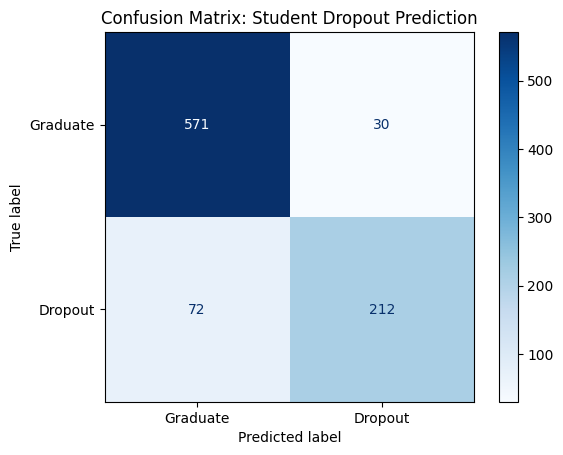

In [ ]:
# Visualizing Accuracy

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=['Graduate', 'Dropout'],
    cmap='Blues'
)
plt.title('Confusion Matrix: Student Dropout Prediction')
plt.show()

This confirms that the model is well\-balanced and highly effective at distinguishing between successful students and those at risk of dropping out\.

After we've seen the Pipeline, let's visualize the predictions\.

In [ ]:
print('Predictions:', predictions)

Predictions: [0 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 1 0 1 1 1 0 0 0
 1 1 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1
 0 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 1 0
 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 1 0 1 0 0 0 1 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0
 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1
 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 1 1 1
 0 1 0 1 0 1 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 1 0
 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 1 1 0 0
 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0
 0 0 0 0 0 0

## Model selection and hyperparameter tuning

In this phase, we transition from a single model to an automated experimental framework\. Because no single algorithm works perfectly for every dataset, we use Hyperparameter tuning to systematically discover the most effective combination of data balancing, feature selection, and classification logic for our student dropout data\.

The goal of this section is threefold:

- Optimization: To find the best internal settings for each algorithm\.

- Comparison: To compete different models against one another\.

- Stability: To ensure the final model isn't just lucky, but is actually picking up on real student behavior patterns\.

### Sampler configurations

In the dataset, we have more graduates than dropouts\. Test different methods to balance the dataset so the model doesn't ignore the dropout minority:

- None: Keep the data as is \(The baseline\)\.

- RandomOverSampler\(\): Duplicate random rows of dropout students until they match the number of graduates\.

- RandomUnderSampler\(\): Delete random rows of graduate students until they match the dropouts\.

- SMOTE: Create synthetic students by looking at the characteristics of existing dropouts and creating new, similar profiles\.

In [ ]:
sampler_configs = [
    {'sampler': [None]}, # No resampling
    {
        'sampler': [RandomOverSampler(random_state=42)],
        'sampler__sampling_strategy': ['minority']
    },
    {
        'sampler': [RandomUnderSampler(random_state=42)],
        'sampler__sampling_strategy': ['majority']
    },
    {
        'sampler' : [SMOTE(random_state=42)]
    }
]

### Dimensionality reduction

We test if reducing our features into a smaller set of principal components improves the signal\-to\-noise ratio\. Too much information can confuse a model\.

- PCA\(\): This compresses the data\. For example, n\_components: \[0\.7\] tries to see if the model can predict dropouts using only 70% of the most important compressed information\.

- LDA\(\): This mathematically squashes the data into a single dimension that best separates Graduates from Dropouts\.

In [ ]:
dim_reduction_configs = [
    {'dim_reduction': [None]},  # No dimensinality reduction
    {
        'dim_reduction': [PCA(random_state=42)],
        'dim_reduction__n_components': [0.7, 0.8, 0.9]
    },
    {
        'dim_reduction': [LDA(n_components=1)]
    }
]

### Classifier configurations

We will compare the performance of 4 different ML algorithms to then evaluate which performs better and with which parameters\. By testing different hyperparameters, we are fine\-tuning these algorithms to fit the specific patterns in the dataset\.

1\. Logistic Regression: This model calculates the probability of a student dropping out\.

- C \(Inverse Regularization Strength\): It governs the tradeoff between fitting the training data accurately and maintaining model simplicity\. A smaller C increases the regularization penalty, leading to a simpler model, whereas a larger C reduces the penalty, allowing for a more complex fit\.

- L1 \(Lasso\): Acts like a filter\. If features have zero impact on dropouts, L1 will ignore them entirely\.

- L2 \(Ridge\): Keeps all features but shrinks their influence so no single variable overwhelms the others\.

2\. Perceptron: It learns by looking at a student's record and making a guess\. If it's wrong, it adjusts its weights\.

- eta0 \(Learning Rate\): This determines how big of a jump the model makes when it learns something new\.

3\. K\-Neighbors Classifier: It makes predictions by identifying the 'K' most similar data points \(neighbors\) in the training set and assigning the class label most common among them\.

- n\_neighbors \[3, 5, 7, 9\]: To predict if Student A will drop out, it finds the n most similar students in the history of the dataset\. If most of those neighbors dropped out, it predicts Student A will too\.

4\. Random Forest: This is an ensemble method that builds multiple decision trees and merges them together to get a more accurate and stable prediction\.

- n\_estimators \[10, 50, 100, 500\]: This controls the number of trees in the forest\. More trees generally lead to better performance and stability but take longer to compute\.

- max\_depth \[None, 10, 20\]: This limits how deep each tree can grow\. A deeper tree can capture very complex patterns but risks memorizing the training data \(overfitting\)\. Limiting the depth forces the model to learn more general rules that apply to new students\.

In [ ]:
classifier_configs = [
    # Logistic Regression

    # L1-regularization
    {
        'classifier': [LogisticRegression(max_iter=1000, random_state=42)],
        'classifier__C': np.logspace(-2, 2, 5),
        'classifier__penalty': ['l1'],
        'classifier__solver': ['saga', 'liblinear']
    },
    # L2-regularization
    {
        'classifier': [LogisticRegression(max_iter=1000, random_state=42)],
        'classifier__C': np.logspace(-2, 2, 5),
        'classifier__penalty': ['l2'],
        'classifier__solver': ['lbfgs']
    },
    # Perceptron
    {
        'classifier': [Perceptron(random_state=42)],
        'classifier__max_iter': [50, 100, 200],
        'classifier__eta0' : loguniform(0.001, 10)
    },
    # KNN
    {
        'classifier': [KNeighborsClassifier(n_jobs=1)],
        'classifier__n_neighbors': [3, 5, 7, 9]
    },
    # Random Forest
    {
        'classifier': [RandomForestClassifier(random_state=42, n_jobs=1)],
        'classifier__n_estimators': [10, 50, 100, 500],
        'classifier__max_depth': [None, 10, 20] # helps prevent overfitting
    }
]

It's important to disclose that preliminary tests indicated that adding an iterative SFS wrapper on top of these models increased computational cost by an order of magnitude without yielding a statistically significant improvement in the F1\-score\. Therefore, relying on the models' intrinsic selection capabilities provided a more efficient and equally robust solution\.

### Cartesian product generation

To identify the optimal model architecture, we now generate a Cartesian product of all preprocessing and classification configurations\.

In [ ]:
pipeline_configs = [
    dict(itertools.chain(*(e.items() for e in configuration)))
    for configuration in itertools.product(
        sampler_configs,
        dim_reduction_configs,
        classifier_configs
    )
]

f'Number of all possible configurations: {len(pipeline_configs)}'

'Number of all possible configurations: 60'

The cartesian product resulted in a search space of 60 unique pipelines\.

### Nested cross\-validation

To identify the most effective predictive architecture, we implement an automated hyperparameter optimization framework\.

- Inner Loop: We utilized RandomizedSearchCV ensuring a comprehensive evaluation of diverse model architectures under 3\-fold cross\-validation\. This strategy balances computational efficiency with statistical rigor\.

In [ ]:
random_search = RandomizedSearchCV(
    starting_pipeline,
    param_distributions=pipeline_configs,
    n_iter=200,
    cv=3,
    scoring='f1',
    n_jobs=-1, # Use all cores
    verbose=1,
    random_state=42
)

- Outer Loop: we apply a 5\-fold cross\_validation to the results of the inner search\. This layer tests the entire search strategy on five independent subsets of the data\. This provides a robust, high\-confidence estimate of the model's stability and predictive power across different student cohorts\.

In [ ]:
scores = cross_validate(
    random_search,
    X_train,
    y_train,
    scoring='f1',
    cv=5, # Outer split: 5 independent folds to validate model stability
    return_estimator=True,  # Save the 5 winning models for final inspection
    return_train_score=True,
    verbose=1,
    n_jobs=1
)

/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [2, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.p

## Results and performance analysis

Now we can get an overview of the performance of the best models\.

In [ ]:
for idx, estimator in enumerate(scores['estimator']):
    best_params = estimator.best_estimator_.get_params()
    print(f"Candidate {idx + 1}:")
    print(f"  Sampler:         {best_params['sampler']}")
    print(f"  Dim Reduction:   {best_params['dim_reduction']}")
    print(f"  Classifier:      {best_params['classifier']}")
    print(f"  Classifier Params: {best_params['classifier'].get_params()}")
    print(f"  Test Score:      {scores['test_score'][idx]:.4f}")
    print("-" * 40)

Candidate 1:
  Sampler:         None
  Dim Reduction:   None
  Classifier:      LogisticRegression(max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')
  Classifier Params: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l1', 'random_state': 42, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
  Test Score:      0.7857
----------------------------------------
Candidate 2:
  Sampler:         None
  Dim Reduction:   None
  Classifier:      LogisticRegression(C=10.0, max_iter=1000, random_state=42)
  Classifier Params: {'C': 10.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
  Test Scor

### Final model evaluation

The results showed that several configurations achieved comparable performance, with differences in cross\-validated scores remaining marginal across the top\-ranked models\. We choose Candidate 5 because it is the best performing\.

Final pipeline architecture:

In [ ]:
selected_pipeline = IMBPipeline([
    ('preprocessor', preprocessor),
    ('sampler', RandomOverSampler(random_state=42, sampling_strategy='minority')),
    ('classifier', LogisticRegression(
        random_state=42,
        penalty='l1',
        solver='liblinear',
        C=1.0,
        max_iter=5000
    ))
])

During hyperparameter tuning with nested cross\-validation, max\_iter was set to 1000 to reduce runtime while still allowing convergence across folds\. For the final selected pipeline, max\_iter was increased to 5000 to ensure full convergence when training on the complete dataset, providing a more robust final model without affecting performance\.

We now run a Randomized Search to find the absolute best strictness \(the C parameter\) for the final model\.  

By testing different values of C, we want to ensure that the model isn't too simple \(underfitting\) or too complex \(overfitting\)\.

In [ ]:
params = {
    'classifier__C': [0.01, 0.1, 1, 10, 50, 100]
}

# cross-validation
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42)

rs_best = RandomizedSearchCV(
    estimator=selected_pipeline,
    param_distributions=params,
    cv=cv,
    n_iter=6,  # we test all values of C
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

Let's check explicitly which are the best hyperparameters of our model\.

In [ ]:
# Fit the updated pipeline
# This will find the single best version of the model
rs_best.fit(X_train, y_train)

print(f"Best C found: {rs_best.best_params_['classifier__C']}")
print(f"Best F1 Score: {rs_best.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [2, 3, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [3, 4, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [2, 4, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11

Finally, we evaluate the model's generalization performance\. We generate predictions on the held\-out Test set \(X\_test\) and calculate the F1\-Score against the true labels \(y\_test\)\. We also compare this to the training score to assess the generalization gap and ensure no significant overfitting occurred\.

In [ ]:
# Final prediction on the untouched X_test
y_test_pred = rs_best.predict(X_test)
final_f1 = f1_score(y_test, y_test_pred)

# Performance on Training set (to compare and check for overfitting)
y_train_pred = rs_best.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred)

--- Final Model Performance ---
F1 Score on Training Set: 0.7924
F1 Score on Test Set:     0.8067
Generalization Gap:       -0.0143
-----------------------------------


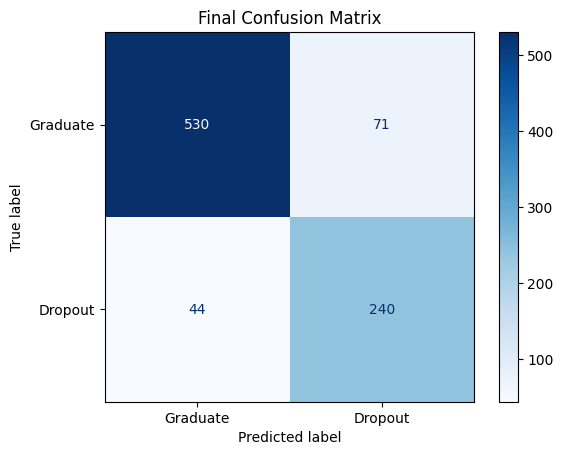

In [ ]:
print(f"--- Final Model Performance ---")
print(f"F1 Score on Training Set: {train_f1:.4f}")
print(f"F1 Score on Test Set:     {final_f1:.4f}")
print(f"Generalization Gap:       {train_f1 - final_f1:.4f}")
print("-" * 35)

# Create the Confusion Matrix for the TEST set
# (shows exactly how many dropouts were correctly caught)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=['Graduate', 'Dropout'],
    cmap='Blues',
)

plt.title("Final Confusion Matrix")
plt.show()

- Top\-Left \(True Graduates\): Students who graduated that the model correctly predicted as safe\.

- Bottom\-Right \(True Dropouts\): These are the students that the model correctly predicted dropped out\.

- Bottom\-Left \(False Graduates\): These are the students who dropped out that the model missed\.

- Top\-Right \(False Alarms\): Students the model flagged as at\-risk who actually graduated\.

Now, we can visualize the learning curve and the validation curve to quantify the bias/variance trade\-off as a function of the size of the training set and the variation of the hyperparameter

C\.

### Learning Curve

Serves as a diagnostic tool that plots the model's performance \(F1\-score\) on both training and validation sets as a function of the number of training samples\. It assesses the generalization behavior of the model by identifying the presence of underfitting \(high bias\) or overfitting \(high variance\)\. It's also essential for determining if the current dataset size is sufficient\.

/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [0, 2, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [0, 2, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [0, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing

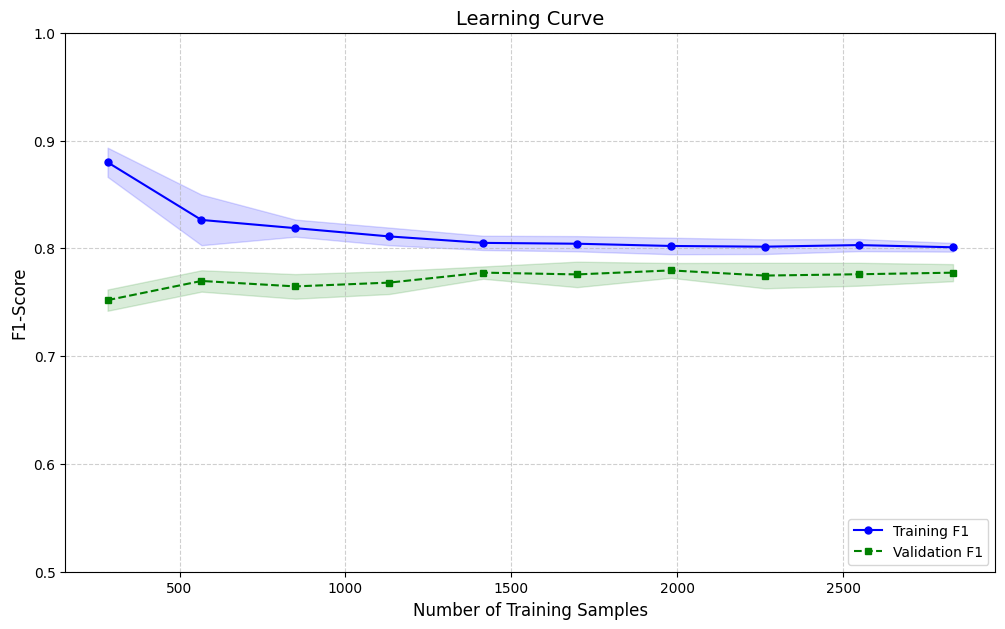

In [ ]:
best_estimator = rs_best.best_estimator_

# Calculate the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    best_estimator,
    X_train,
    y_train,
    cv=5, # 5-fold cross-validation
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualization
plt.figure(figsize=(12, 7))

# Plot Training F1
plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training F1')
plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

# Plot Validation F1 ('test_scores' from the CV)
plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation F1')
plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

# Formatting
plt.title('Learning Curve', fontsize=14)
plt.xlabel('Number of Training Samples', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')
plt.ylim([0.5, 1.0])
plt.show()

The Learning Curve confirms a highly robust pipeline\. The primary finding in this curve is the convergence of the Training F1 \(solid blue line\) and the Validation F1 \(dashed green line\)\. As the number of samples increases, the gap between the two lines narrows significantly\. This indicates that the model is successfully generalizing from the patterns it has learned rather than simply memorizing the training data\.

Furthermore, the stabilization of the validation score at approximately 0\.80 \(1500 samples\) suggests that the model has effectively captured the underlying predictive signals within the dataset without overfitting to noise\. This confirms that the dataset size is sufficient\.

### Validation Curve

We now want to verify that the model is correctly optimized, and to do that we use the Validation Curve\.

It focuses on the impact of the hyperparameter C\. This analysis allows us to visually confirm the point at which the model achieves its peak predictive power on unseen data without falling into the traps of underfitting or overfitting\.

/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:2

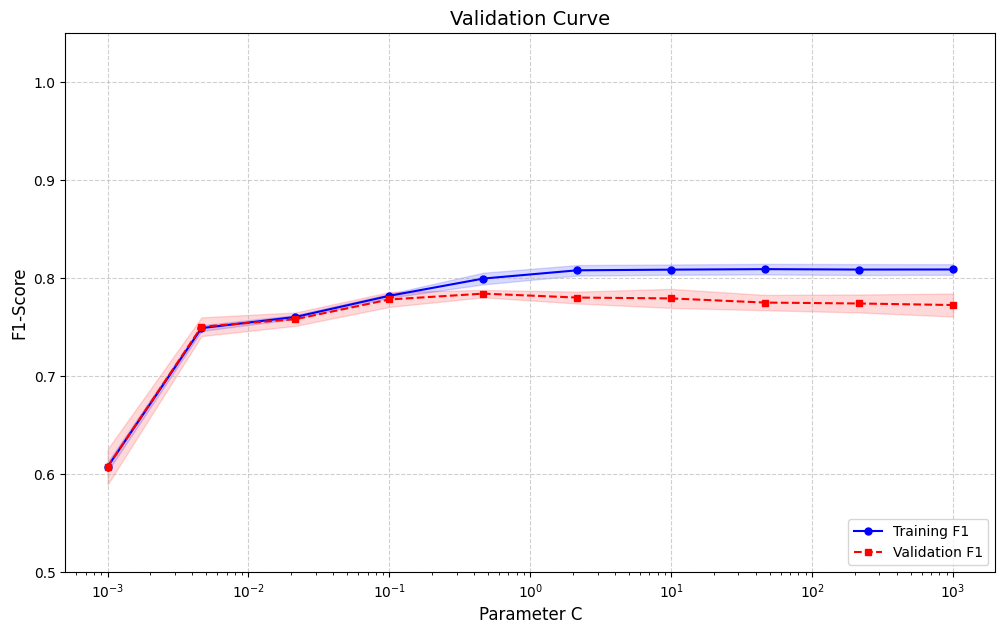

In [ ]:
param_range = np.logspace(-3, 3, 10)  # C range

# Calculate the validation curve
train_scores, test_scores = validation_curve(
    best_estimator,
    X_train,
    y_train,
    param_name='classifier__C',
    param_range=param_range,
    cv=5,
    n_jobs=-1,
    scoring='f1'
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualization
plt.figure(figsize=(12, 7))

# Training Score
plt.plot(param_range, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training F1')
plt.fill_between(param_range,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

# Validation Score
plt.plot(param_range, test_mean,
         color='red', linestyle='--',
         marker='s', markersize=5,
         label='Validation F1')
plt.fill_between(param_range,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='red')

# Formatting
plt.title('Validation Curve', fontsize=14)
plt.xlabel('Parameter C', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xscale('log') # Log scale is essential for C
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')
plt.ylim([0.5, 1.05])
plt.show()

The Validation Curve for the hyperparameter C confirms that the model is highly robust across a wide range of values\. The optimal balance between bias and variance is achieved between C=0\.1 and C=1\.0\.

Values of C < 0\.1 result in underfitting, as indicated by a simultaneous drop in both training and validation performance\. Conversely, as C increases beyond 1, we observe a slight divergence between the training and validation curves, suggesting the onset of overfitting\.

This empirical evidence justifies our selection of C=1\.0, as it maximizes predictive power while maintaining strong generalization to unseen data\.

## Conclusion

In this project, we developed a robust machine learning pipeline to predict student dropout risk, providing educational institutions with a data\-driven tool for early intervention\.

After extensive evaluation via Nested cross\-validation, the final architecture selected was a Logistic regression model with L1 \(Lasso\) regularization, supported by Random over\-Sampling\.

A key strategic decision in this workflow was the omission of Sequential Feature Selection \(SFS\)\. While SFS is a powerful wrapper\-based approach, it is computationally intensive and can introduce additional variance due to its iterative nature, particularly when embedded within a nested cross\-validation framework\. Instead, feature selection was handled implicitly through the use of L1\-regularized logistic regression, which performs embedded feature selection\. This approach offers a more computationally efficient and stable alternative, while remaining well\-aligned with the cross\-validation strategy and preserving generalization performance\.

Furthermore, although non\-linear ensemble methods \(Random Forest\) were tested, Logistic Regression was chosen for the final pipeline due to its superior interpretability\. In the social sciences, understanding the "why" is fundamental\. The linear nature of this model allows administrators to extract clear, weighted coefficients for each feature, identifying specific academic or socio\-economic risk factors that drive dropout probability\.

In fact, by extracting the highest coefficients from the final pipeline, we can identify the top five predictors of dropout\. This transformation of complex data into a clear hierarchy of risk factors allows educational stakeholders to understand why a student is leaving and can lead to targeted interventions where they are needed most\.

In [ ]:
feature_names = rs_best.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
coefficients = rs_best.best_estimator_.named_steps['classifier'].coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by the highest positive values (top causes of dropout)
top_dropout_causes = importance_df.sort_values(by='Coefficient', ascending=False).head(5)

print("--- Top 5 Main Causes of Student Dropout ---")
print(top_dropout_causes[['Feature', 'Coefficient']].to_string(index=False))

--- Top 5 Main Causes of Student Dropout ---
                      Feature  Coefficient
cat__previous_qualification_4     2.197590
cat__fathers_qualification_30     1.753482
cat__mothers_qualification_19     1.723874
   cat__fathers_occupation_12     1.291755
               cat__course_16     1.284620


Although academic performance and financial variables are commonly linked to student dropout, the model identifies socio\-academic background factors and course\-related indicators as the strongest predictors of dropout risk\.

In particular, parental education and occupation, prior educational background, and enrollment in specific degree programs show the largest positive associations with attrition in the fitted model\. This suggests that contextual factors may already place some students at higher risk, even before academic difficulties become evident\.

## References

- Scikit\-learn User Guide


- Kaggle dataset: https://www\.kaggle\.com/datasets/marouandaghmoumi/dropout\-and\-success\-student\-data\-analysis

- Deepnote notebooks of the first module of the course \[509486\] Machine Learning, Artificial Neural Networks and Deep Learning from the BSc in Artificial Intelligence, University of Pavia\.